In [5]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
import anndata
import torch
import csv
import gzip
import gseapy
import scipy.io
import numpy as np 
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}



In [6]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided'
cluster_resolution = 0.05
subcluster_resolution = 0.20

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/%s/scvi_res/clustering/res_%s' % (head_folder,hvg_to_use,cluster_resolution)
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_1' % head_folder
if not os.path.exists(folder_out):
    os.makedirs(folder_out)
marker_folder_out = '%s/cluster_markers' % folder_out
if not os.path.exists(marker_folder_out):
    os.makedirs(marker_folder_out)

# parameters
confidence = 90
de_mag_thresh = 0.1 / np.log10(np.e) # 0.1 / np.log10(np.e)
num_de_clusters_thresh = 1
upreg_expression_in_cluster_of_interest_thresh = -7 / np.log10(np.e)





In [7]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [8]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [9]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

descriptions = list(adata.obs['description'].unique())
clusters = list(adata.obs['cluster'].unique())
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))

# clusters = [0, 1, 2, 3]
# descriptions = ['male aligned bmal1-ko', 
#                 'male misaligned bmal1-control', 
#                 'female aligned bmal1-ko', 
#                 'female misaligned bmal1-control', 
#                 'male aligned bmal1-control', 
#                 'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)





Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3, 6, 5, 4, 7, 8]


In [12]:
# --- ADD CELL TYPE NAMES TO ADATA ---


adata = adata[~np.isnan(adata.obs['cluster'])]


cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                  ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial 2', 'Neuron']))


adata.obs['Cell type'] = list(map(lambda x: cluster_cell_type_dict[x], adata.obs['cluster']))




/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_70312/2027220422.py:11: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Cell type'] = list(map(lambda x: cluster_cell_type_dict[x], adata.obs['cluster']))


In [13]:
# --- OPTIONAL: LIMIT TO MAIN CELL TYPES ---

adata = adata[np.isin(adata.obs['Cell type'], ['SMC', 'Fibroblast', "Endothelial", 'Macrophage', 'T'])]
adata


View of AnnData object with n_obs × n_vars = 141752 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster', 'Cell type'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


<Figure size 1200x1200 with 0 Axes>

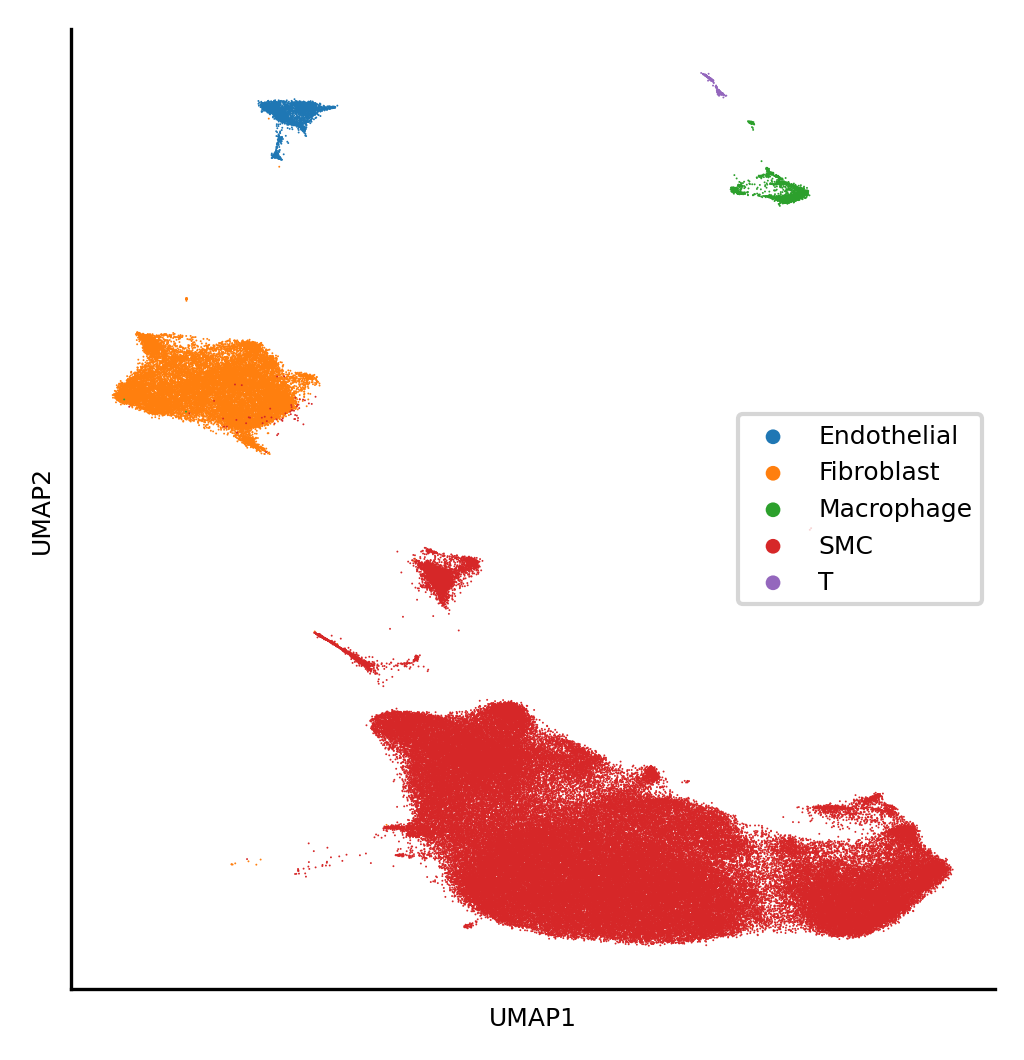

In [17]:
# --- VISUALIZE THE CELLS IN LOW - D ---
import scanpy


# ** set the scanpy plotting parameters **
scanpy.set_figure_params(scanpy=False, dpi=300, dpi_save=300, frameon=True, vector_friendly=True, fontsize=7,figsize=(4,4))



# ** viz **
import seaborn as sns
fig = plt.figure(dpi=300) # figsize=(10,5),
ax = scanpy.pl.scatter(adata, basis="scVI_umap",color=['Cell type'],show=False)
fig.axes.append(ax)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
sns.despine()
lgnd = plt.legend(loc="right", scatterpoints=1, fontsize=6)
for handle in lgnd.legendHandles:
    handle.set_sizes([50])
fileout = '%s/cell_low_d_colored_by_cell_type.pdf' % marker_folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()






TEMP: GET RID OF T CELLS
TEMP: GET RID OF T CELLS
TEMP: GET RID OF T CELLS
TEMP: GET RID OF T CELLS
TEMP: GET RID OF T CELLS


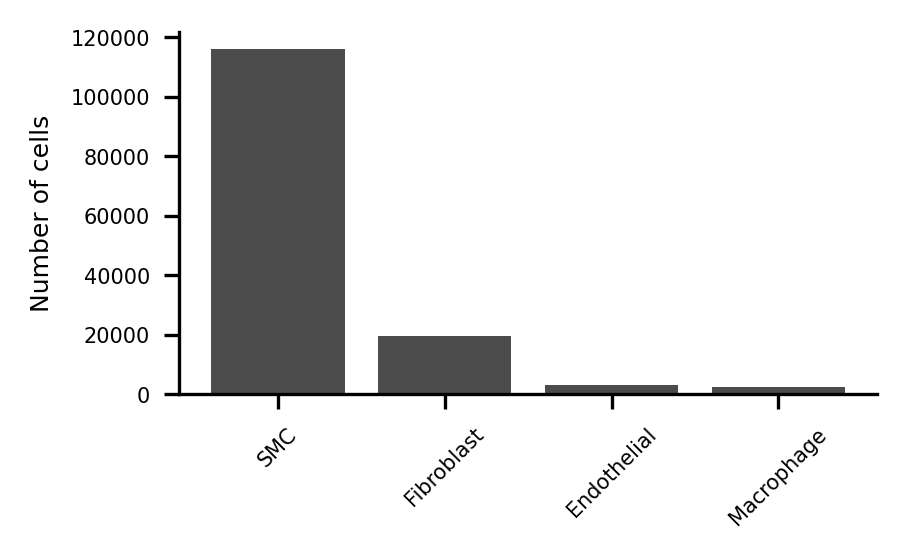

In [18]:
# --- HISTOGRAM OF CELL COUNTS BY CELL TYPE ---




cluster_cell_type_names = []
counts = []
for cluster in sorted(list(adata.obs['cluster'].unique())):
    print("TEMP: GET RID OF T CELLS")
    if cluster >= 4:
        continue
    counts.append(np.sum(adata.obs['cluster'] == cluster))
    cluster_cell_type_names.append(cluster_cell_type_dict[cluster])
    
    
fig = plt.figure(figsize=(3,1.6),dpi=300)
plt.bar(cluster_cell_type_names,counts,color='k',alpha=0.7)
plt.xticks(rotation=45)
sns.despine()
plt.ylabel("Number of cells")
fileout = '%s/cell_type_count.pdf' % marker_folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()


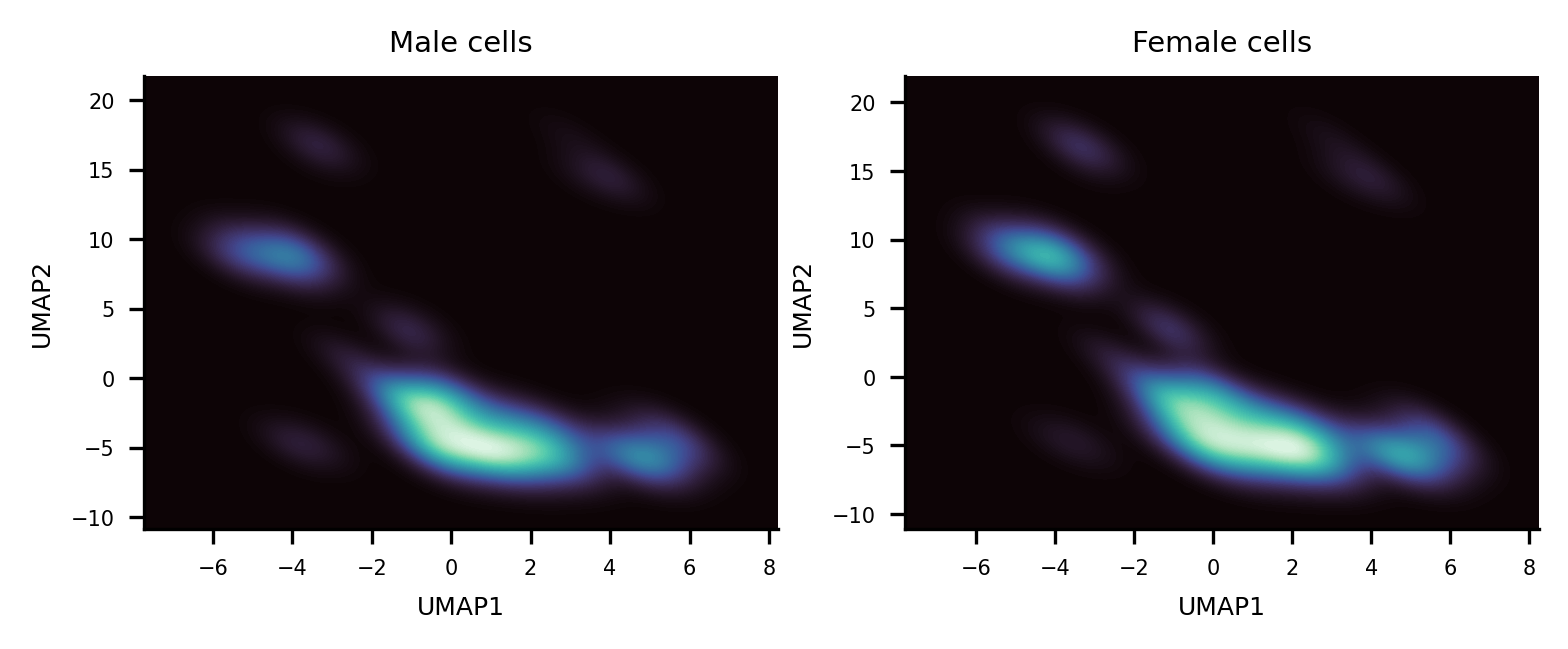

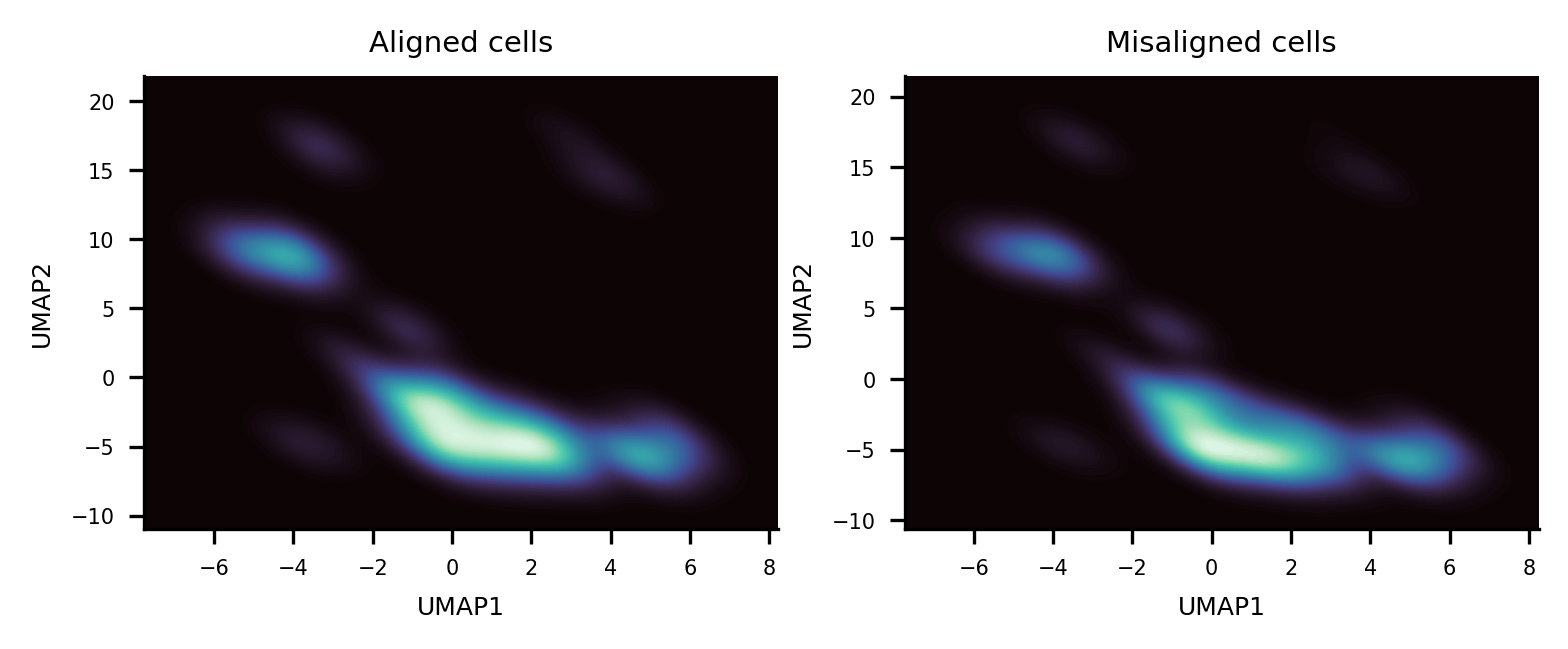

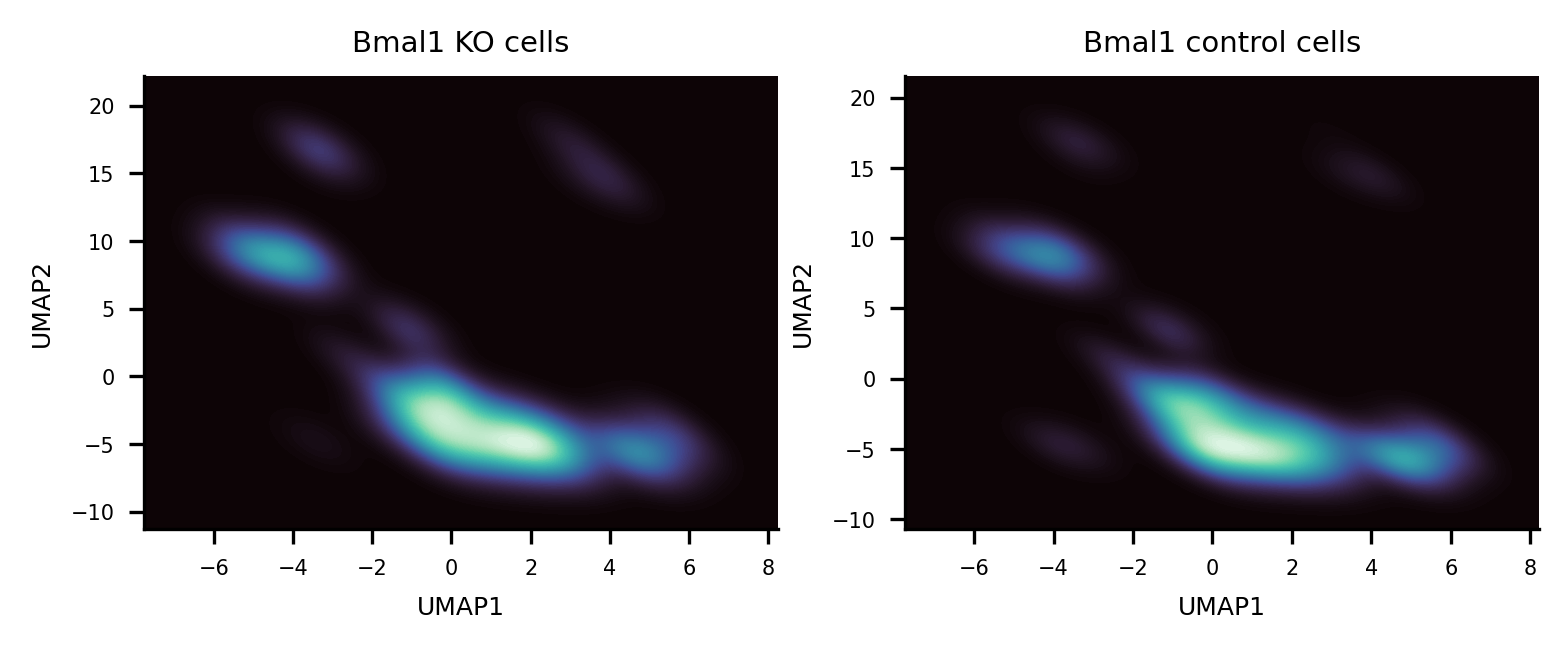

In [41]:
# --- VISUALIZE DENSITY OF THE CELLS BY SEX, KO, MISALIGNMENT ---

# ** set the scanpy plotting parameters **
scanpy.set_figure_params(scanpy=False, dpi=300, dpi_save=300, frameon=True, vector_friendly=True, fontsize=7)
cols = ['sex','misaligned','bmal1_ko']
for col in cols:
    adata.obs[col] = adata.obs[col].astype('category')

    # ** set the val and coords of the axes **
    val_list = list(adata.obs[col].unique())
    coord_list = [0,1]


    # ** viz **
    import seaborn as sns
    fig, axs = plt.subplots(nrows = 1, ncols=2, figsize = (6,2),dpi=300)
    for val, coord in zip(val_list,coord_list):

        # get val adata
        val_adata = adata[adata.obs[col] == val]
        
        # set the descriptoin
        if col == 'sex':
            description = val.capitalize()
        elif col == 'misaligned':
            description = 'Misaligned' if val else 'Aligned'
        elif col == 'bmal1_ko':
            description = 'Bmal1 KO' if val else 'Bmal1 control'

        # plot
        axs[coord].scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],c='b',s=1,label='All cells')
        axs[coord].scatter(val_adata.obsm['X_scVI_umap'][:,0],val_adata.obsm['X_scVI_umap'][:,1],c='r',s=0.1,label='%s cells' % description)

        
        
        import helper_functions
        import importlib
        importlib.reload(helper_functions)
        val_adata=val_adata[np.random.choice(np.arange(0,val_adata.shape[0]),10000)]
        axs[coord]=helper_functions.viz_cell_density(x_vals = val_adata.obsm['X_scVI_umap'][:,0],
            y_vals = val_adata.obsm['X_scVI_umap'][:,1],
            x_col = 'UMAP1',
            y_col = 'UMAP2',
            title = None,
            cmap = 'mako',
            xlim_tuple=None,
            ylim_tuple=None,
            dpi=200,
            ax=axs[coord],
            show=False)
    
    
        
        axs[coord].set_xlabel('UMAP1')
        axs[coord].set_ylabel('UMAP2')
        axs[coord].set_title('%s cells' % description)
    sns.despine()
    fileout = '%s/cell_density_by_%s.png' % (marker_folder_out, col)
    plt.savefig(fileout,bbox_inches='tight')
    plt.show()


            





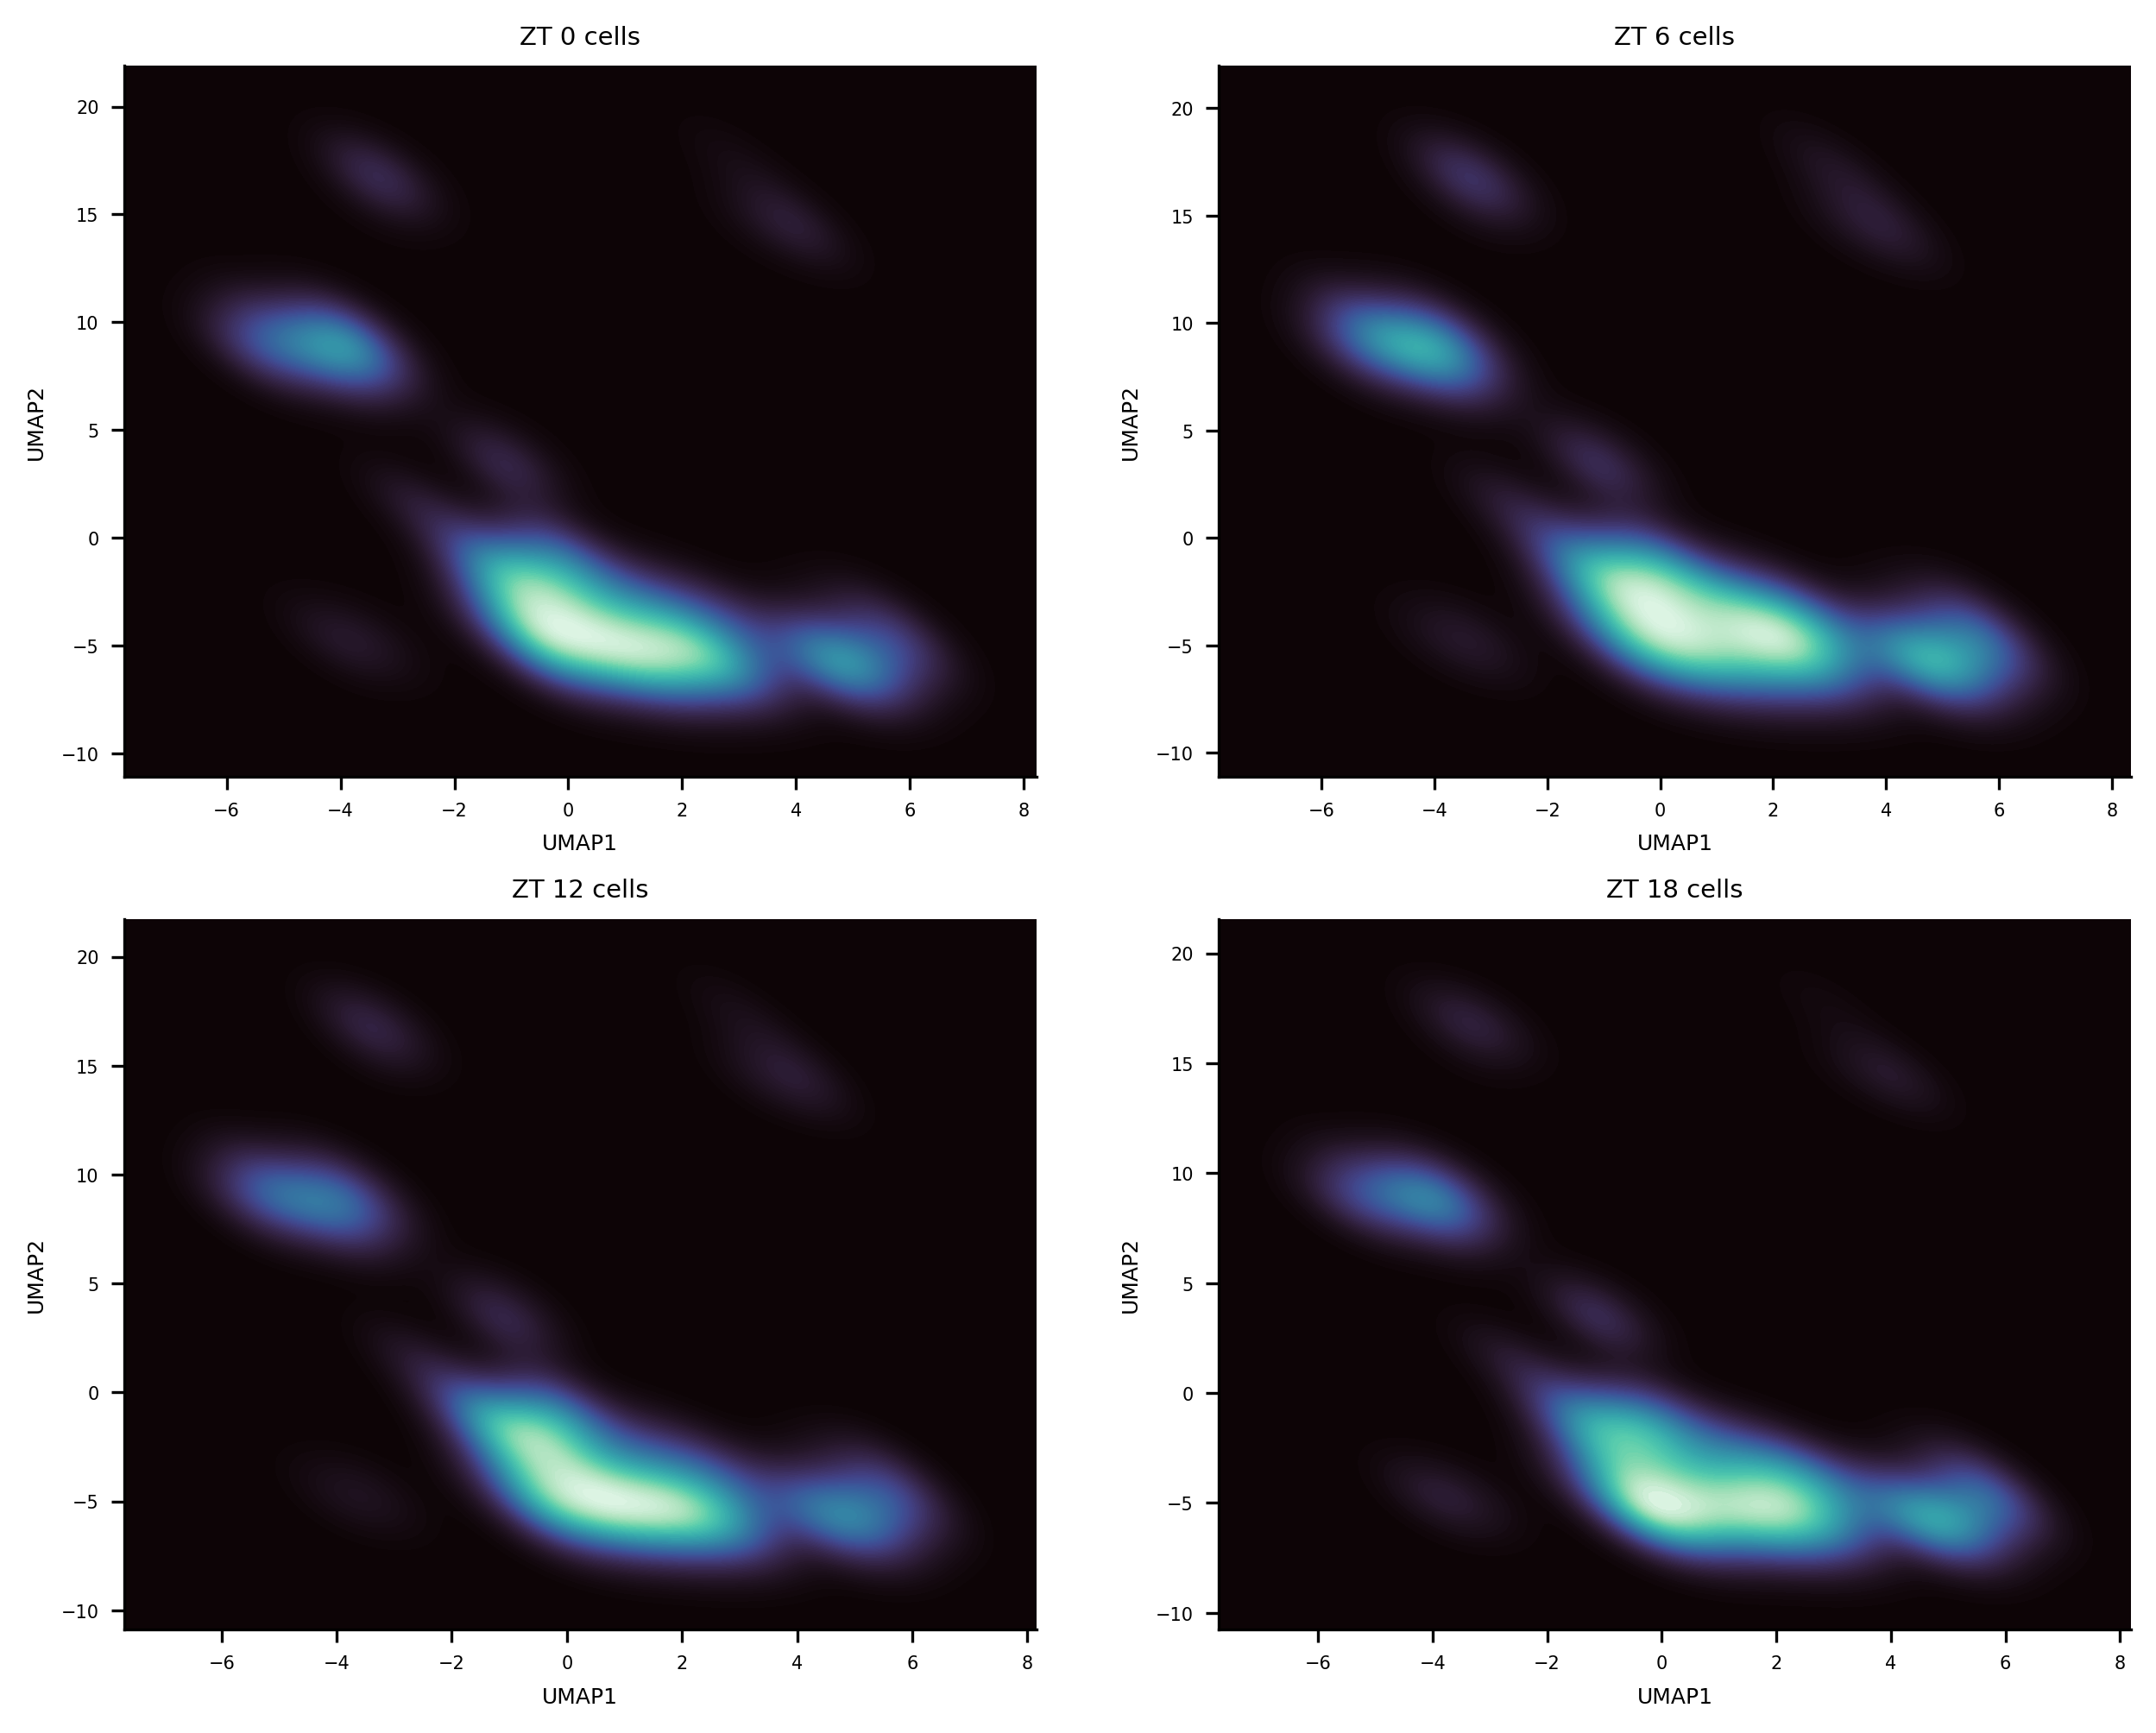

In [42]:
# --- VISUALIZE THE CELLS BY TIME ---

# ** set the scanpy plotting parameters **
scanpy.set_figure_params(scanpy=False, dpi=300, dpi_save=300, frameon=True, vector_friendly=True, fontsize=7)
adata.obs['zt'] = adata.obs['zt'].astype('category')

# ** set the zt and coords of the axes **
zt_list = [0,6,12,18]
coord_list = [[0,0],[0,1],[1,0],[1,1]]


# ** viz **
import seaborn as sns
fig, axs = plt.subplots(nrows = 2, ncols=2, figsize = (10,8),dpi=300)
for zt, coord in zip(zt_list,coord_list):
    
    # get zt adata
    zt_adata = adata[adata.obs['zt'] == zt]
    

    
            
    import helper_functions
    import importlib
    importlib.reload(helper_functions)
    zt_adata=zt_adata[np.random.choice(np.arange(0,zt_adata.shape[0]),10000)]
    axs[coord[0],coord[1]]=helper_functions.viz_cell_density(x_vals = zt_adata.obsm['X_scVI_umap'][:,0],
        y_vals = zt_adata.obsm['X_scVI_umap'][:,1],
        x_col = 'UMAP1',
        y_col = 'UMAP2',
        title = None,
        cmap = 'mako',
        xlim_tuple=None,
        ylim_tuple=None,
        dpi=200,
        ax=axs[coord[0],coord[1]],
        show=False)



    axs[coord[0],coord[1]].set_xlabel('UMAP1')
    axs[coord[0],coord[1]].set_ylabel('UMAP2')
    axs[coord[0],coord[1]].set_title('ZT %s cells' % zt)

    
sns.despine()
fileout = '%s/cell_density_by_time.pdf' % (marker_folder_out)
plt.savefig(fileout,bbox_inches='tight')
plt.show()






In [43]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [44]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)




22193

In [45]:
# --- DEFINE FUNCTION TO GET THE FFT SAMPLES ---

def get_log_prop_samples_and_fft(cluster,description,num_grid_points,num_samples,gene_list=None):
    
    # ** load metric df **
    metric_path = '%s/de_novo_metrics.tsv' % cluster_description_folder_out_dict[cluster][description]
    metric_df = pd.read_table(metric_path,index_col='gene',sep='\t')

    # ** load gene parameters **
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_beta_path = '%s/gene_log_beta.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_min_max_path = '%s/log_min_max.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    if gene_list is not None:
        gene_log_alpha_df = gene_log_alpha_df.loc[gene_list]
        gene_log_beta_df = gene_log_beta_df.loc[gene_list]
        gene_log_min_max_df = gene_log_min_max_df.loc[gene_list]
    gene_log_min = torch.Tensor(np.array(gene_log_min_max_df['log_min'])) 
    gene_log_max = torch.Tensor(np.array(gene_log_min_max_df['log_max'])) 
    
    
    # ** get the log_prop_dist obj **
    log_prop_dist = torch.distributions.beta.Beta(torch.Tensor(np.exp(np.array(gene_log_alpha_df)).T), torch.Tensor(np.exp(np.array(gene_log_beta_df))).T)

    # ** sample the waveforms **
    sampled_log_prop = log_prop_dist.sample((num_samples,)) # [num_samples x num_time_points x num_genes]
    sampled_log_prop = (sampled_log_prop * (gene_log_max.unsqueeze(0).unsqueeze(0) - gene_log_min.unsqueeze(0).unsqueeze(0))) + gene_log_min.unsqueeze(0).unsqueeze(0)

    # ** compute the sampled fft **
    fft_res = np.fft.fft(sampled_log_prop,axis=1)
    
    return sampled_log_prop, fft_res








In [46]:
# --- SET THE DESCRIPTION TO JUST THE ALIGNED MALE CONTROL ---

description = 'male aligned bmal1-control'



In [47]:
# --- DEFINE FN TO LOAD PARAMS FROM PATH ---

def load_param_dfs_from_path(res_folder):
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % res_folder
    gene_log_beta_path = '%s/gene_log_beta.tsv' % res_folder
    gene_log_min_max_path = '%s/log_min_max.tsv' % res_folder
    gene_stat_path = '%s/de_novo_metrics.tsv' % res_folder
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    gene_stat_df = pd.read_table(gene_stat_path,sep='\t',index_col='gene')
    return gene_log_alpha_df, gene_log_beta_df, gene_log_min_max_df,gene_stat_df




In [48]:
# --- LET'S JUST LIMIT THE CLUSTER TO THE MAIN CELL TYPES ---


clusters = list(range(0,4))
clusters


[0, 1, 2, 3]

In [49]:
# --- GET THE GENES THAT WERE ESTIMATED FOR ALL CLUSTERS ---

common_genes = None
for cluster in clusters:
    gene_log_alpha_df, _, _, _ = load_param_dfs_from_path(cluster_description_folder_out_dict[cluster]['male aligned bmal1-control'])
    current_genes = set(gene_log_alpha_df.index)
    if common_genes is None:
        common_genes = current_genes
    common_genes = common_genes.intersection(current_genes)
    print(len(current_genes))
common_genes = np.array(list(common_genes))

len(common_genes)


20535
18853
15499
15075


13160

In [ ]:
# --- GET SAMPLED WAVEFORMS AND FFT'S FOR EACH CLUSTER ---

num_grid_points = 4
num_samples = 300
mesor_sampled_mat = np.zeros((len(clusters), num_samples, len(common_genes)))

for cluster in clusters:
    
    # ** get sampled log prop and FFT **
    sampled_log_prop, fft_res = get_log_prop_samples_and_fft(cluster,description,num_grid_points,num_samples,gene_list=common_genes)

    # ** compute the sampled fft **
    fft_res = np.fft.fft(sampled_log_prop,axis=1)
    freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
    periods = 1 / freqs
    amps = abs(fft_res)
    circadian_index = np.where(np.isin(periods,[24]))[0]

    # get mesor samples
    mesor_samples = torch.mean(sampled_log_prop,dim=1).numpy()
    mesor_sampled_mat[cluster,:,:] = mesor_samples



/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_14903/295275852.py:15: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_14903/295275852.py:15: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs


In [89]:
# --- FOR EACH PAIR OF CLUSTERS, COMPUTE THE FRACTION ---


up_marker_list_of_lists = []
down_marker_list_of_lists = []
marker_list_of_lists = []
for cluster_index in range(0,len(clusters)):


    dif_mat = mesor_sampled_mat[cluster_index,:,:] - mesor_sampled_mat # [num_clusters x num_samples x num_genes]
    high_dif_mat = np.percentile(dif_mat,confidence,axis=1) # [num_clusters x num_genes]
    low_dif_mat = np.percentile(dif_mat,100-confidence,axis=1) # [num_clusters x num_genes]


    
    # find DE genes
    bool_de_mat = (low_dif_mat < 0) | (high_dif_mat > 0) # [num_clusters x num_genes]
    is_de_genes = (np.sum(bool_de_mat,axis=0) >= num_de_clusters_thresh) # [num_genes]
    
    # find genes with adequately high expression in the cluster of interest
    mesor_est_in_cluster_of_interest = np.median(mesor_sampled_mat[cluster_index,:,:],axis=0)
    is_highly_expressed = mesor_est_in_cluster_of_interest >= upreg_expression_in_cluster_of_interest_thresh
    
    # compute the magnitude of the DE
    point_de_est = np.mean(dif_mat,axis=1) # [num_clusters x num_genes]
    point_de_est_minus_cluster_of_interest = np.concatenate((point_de_est[:cluster_index,:],point_de_est[cluster_index+1:,:]),axis=0) # [(num_clusters - 1) x num_genes]

    # get the upregulated genes
    upreg_magnitude = np.min(point_de_est_minus_cluster_of_interest,axis=0)
    upreg_magnitude = upreg_magnitude * is_de_genes.astype(int)
    upreg_magnitude = upreg_magnitude * (upreg_magnitude >= de_mag_thresh).astype(int)
    upreg_magnitude = upreg_magnitude * is_highly_expressed.astype(int)
    up_ranked_gene_indices = np.flip(np.argsort(upreg_magnitude))
    up_ranked_gene_indices = up_ranked_gene_indices[upreg_magnitude[up_ranked_gene_indices] != 0] # limit to the ones w/ non-zero effect

    # get the downregulated genes
    downreg_magnitude = np.max(point_de_est_minus_cluster_of_interest,axis=0)
    downreg_magnitude = downreg_magnitude * is_de_genes.astype(int)
    downreg_magnitude = downreg_magnitude * (downreg_magnitude <= -1 * de_mag_thresh).astype(int)
    down_ranked_gene_indices = np.argsort(downreg_magnitude)
    down_ranked_gene_indices = down_ranked_gene_indices[downreg_magnitude[down_ranked_gene_indices] != 0] # limit to the ones w/ non-zero effect

    
    # get the up regulated markers
    up_markers = np.array(common_genes)[up_ranked_gene_indices]
    
    # get the down regulated markers
    down_markers = np.array(common_genes)[down_ranked_gene_indices]
    
    # get the top markers (agnostic to up or down)
    cluster_markers = np.array(list(up_markers) + list(down_markers))
    cluster_marker_magnitudes = np.abs(np.array(list(upreg_magnitude[up_ranked_gene_indices] / np.log(10)) + list(downreg_magnitude[down_ranked_gene_indices] / np.log(10))))
    top_cluster_marker_indices = np.flip(np.argsort(cluster_marker_magnitudes))
    

    # if no DE markers, toss error
    if len(cluster_markers) == 0: # if len(up_markers) == 0:
        raise Exception("Error: no marker genes for cluster %s" % cluster_index)
    
    
    # add to list
    up_marker_list_of_lists.append(list(up_markers))
    down_marker_list_of_lists.append(list(down_markers))
    marker_list_of_lists.append(list(cluster_markers))
    
    # write out the upregulated marker genes
    subfolder = '%s/up_markers' % marker_folder_out
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    upreg_df = pd.DataFrame()
    upreg_df['gene'] = common_genes
    upreg_df['log10_magnitude'] = upreg_magnitude / np.log(10)
    upreg_df = upreg_df.set_index('gene')
    upreg_df = upreg_df[upreg_df['log10_magnitude'] > 0]
    upreg_df = upreg_df.sort_values(['log10_magnitude'],ascending=False)
    fileout = '%s/cluster_%s.tsv' % (subfolder,cluster_index)
    upreg_df.to_csv(fileout,sep='\t')
    
    # write out the downregulated marker genes
    subfolder = '%s/down_markers' % marker_folder_out
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    downreg_df = pd.DataFrame()
    downreg_df['gene'] = common_genes
    downreg_df['log10_magnitude'] = downreg_magnitude / np.log(10)
    downreg_df = downreg_df.set_index('gene')
    downreg_df = downreg_df[downreg_df['log10_magnitude'] < 0]
    downreg_df = downreg_df.sort_values(['log10_magnitude'],ascending=True)
    fileout = '%s/cluster_%s.tsv' % (subfolder,cluster_index)
    downreg_df.to_csv(fileout,sep='\t')
    
    
    
    print("%s: num up: %s" % (cluster_index,len(up_ranked_gene_indices)))
    print("%s: num down: %s" % (cluster_index,len(down_ranked_gene_indices)))





0: num up: 1592
0: num down: 1980
1: num up: 1329
1: num down: 865
2: num up: 1643
2: num down: 1102
3: num up: 2887
3: num down: 3701


In [91]:
# --- LOOK AT ENRICHMENT FOR THE UPREGULATED GENES ---

import warnings
warnings.filterwarnings("ignore")


# for cluster in clusters:
for cluster in [3]:


    # set the enrichment gene sets
    enrichment_gene_sets = ['GO_Biological_Process_2018','KEGG_2016', 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X']

    
    # get the background list
#     background_list = []
#     for l in up_marker_list_of_lists:
#         background_list += l
    background_list = list(reg_genes_to_est)
    
    # get enrichment results
    res = gseapy.enrichr(gene_list=up_marker_list_of_lists[cluster],
                         gene_sets = enrichment_gene_sets,
                        organism = 'mouse',
                        background=background_list)
    # get the DF
    res_df = res.results
    res_df = res_df.set_index("Gene_set")

    # fileout
    subfolder = '%s/up_marker_enrichment' % marker_folder_out
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    fileout = '%s/cluster_%s.tsv' % (subfolder,cluster)
    res_df.to_csv(fileout,sep='\t')




In [35]:
# --- LOOK AT ENRICHMENT FOR THE DOWNREGULATED GENES ---

import warnings
warnings.filterwarnings("ignore")


for cluster in clusters:


    # set the enrichment gene sets
    enrichment_gene_sets = ['GO_Biological_Process_2018','KEGG_2016', 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X']

    # get the background list
#     background_list = []
#     for l in down_marker_list_of_lists:
#         background_list += l
    background_list = list(reg_genes_to_est)
    
    
    # get enrichment results
    res = gseapy.enrichr(gene_list=down_marker_list_of_lists[cluster],
                         gene_sets = enrichment_gene_sets,
                        organism = 'mouse',
                        background=background_list)

    # get the DF
    res_df = res.results
    res_df = res_df.set_index("Gene_set")

    # fileout
    subfolder = '%s/down_marker_enrichment' % marker_folder_out
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    fileout = '%s/cluster_%s.tsv' % (subfolder,cluster)
    res_df.to_csv(fileout,sep='\t')





2022-09-06 12:16:02,454 Warning: No enrich terms using library GO_Biological_Process_2018 when cutoff = 0.05
2022-09-06 12:16:04,931 Warning: No enrich terms using library KEGG_2016 when cutoff = 0.05
2022-09-06 12:16:12,805 Warning: No enrich terms using library GO_Biological_Process_2018 when cutoff = 0.05


In [80]:
# --- MAKE THE MARKER ADATA FOR THE MARKERS ---


num_top_genes_per_cluster = 2
list_of_lists = list(map(lambda x: x[:num_top_genes_per_cluster],up_marker_list_of_lists))


marker_genes = np.array(list_of_lists).flatten()
print("MANUALLY SETTING MARKER GENES")
marker_genes = ['Myh11', 'Serpinf1', 'Pecam1', 'Cd68']
marker_gene_indices = np.where(np.isin(common_genes,marker_genes))[0]
marker_X = torch.Tensor(mesor_sampled_mat[:,:,marker_gene_indices]).flatten(start_dim=0,end_dim=1).numpy() # [(num_clusters * num_samples) x num_marker_genes]
marker_X = marker_X / np.log(10)
sample_ids = []
sample_names = []
for cluster in sorted(clusters):
    sample_ids += [cluster] * num_samples
    sample_names += [cluster_cell_type_dict[cluster]] * num_samples
marker_adata = anndata.AnnData(X = marker_X)
marker_adata.obs['cluster_id'] = sample_ids
marker_adata.obs['cluster_name'] = sample_names
marker_adata.var_names = common_genes[marker_gene_indices]



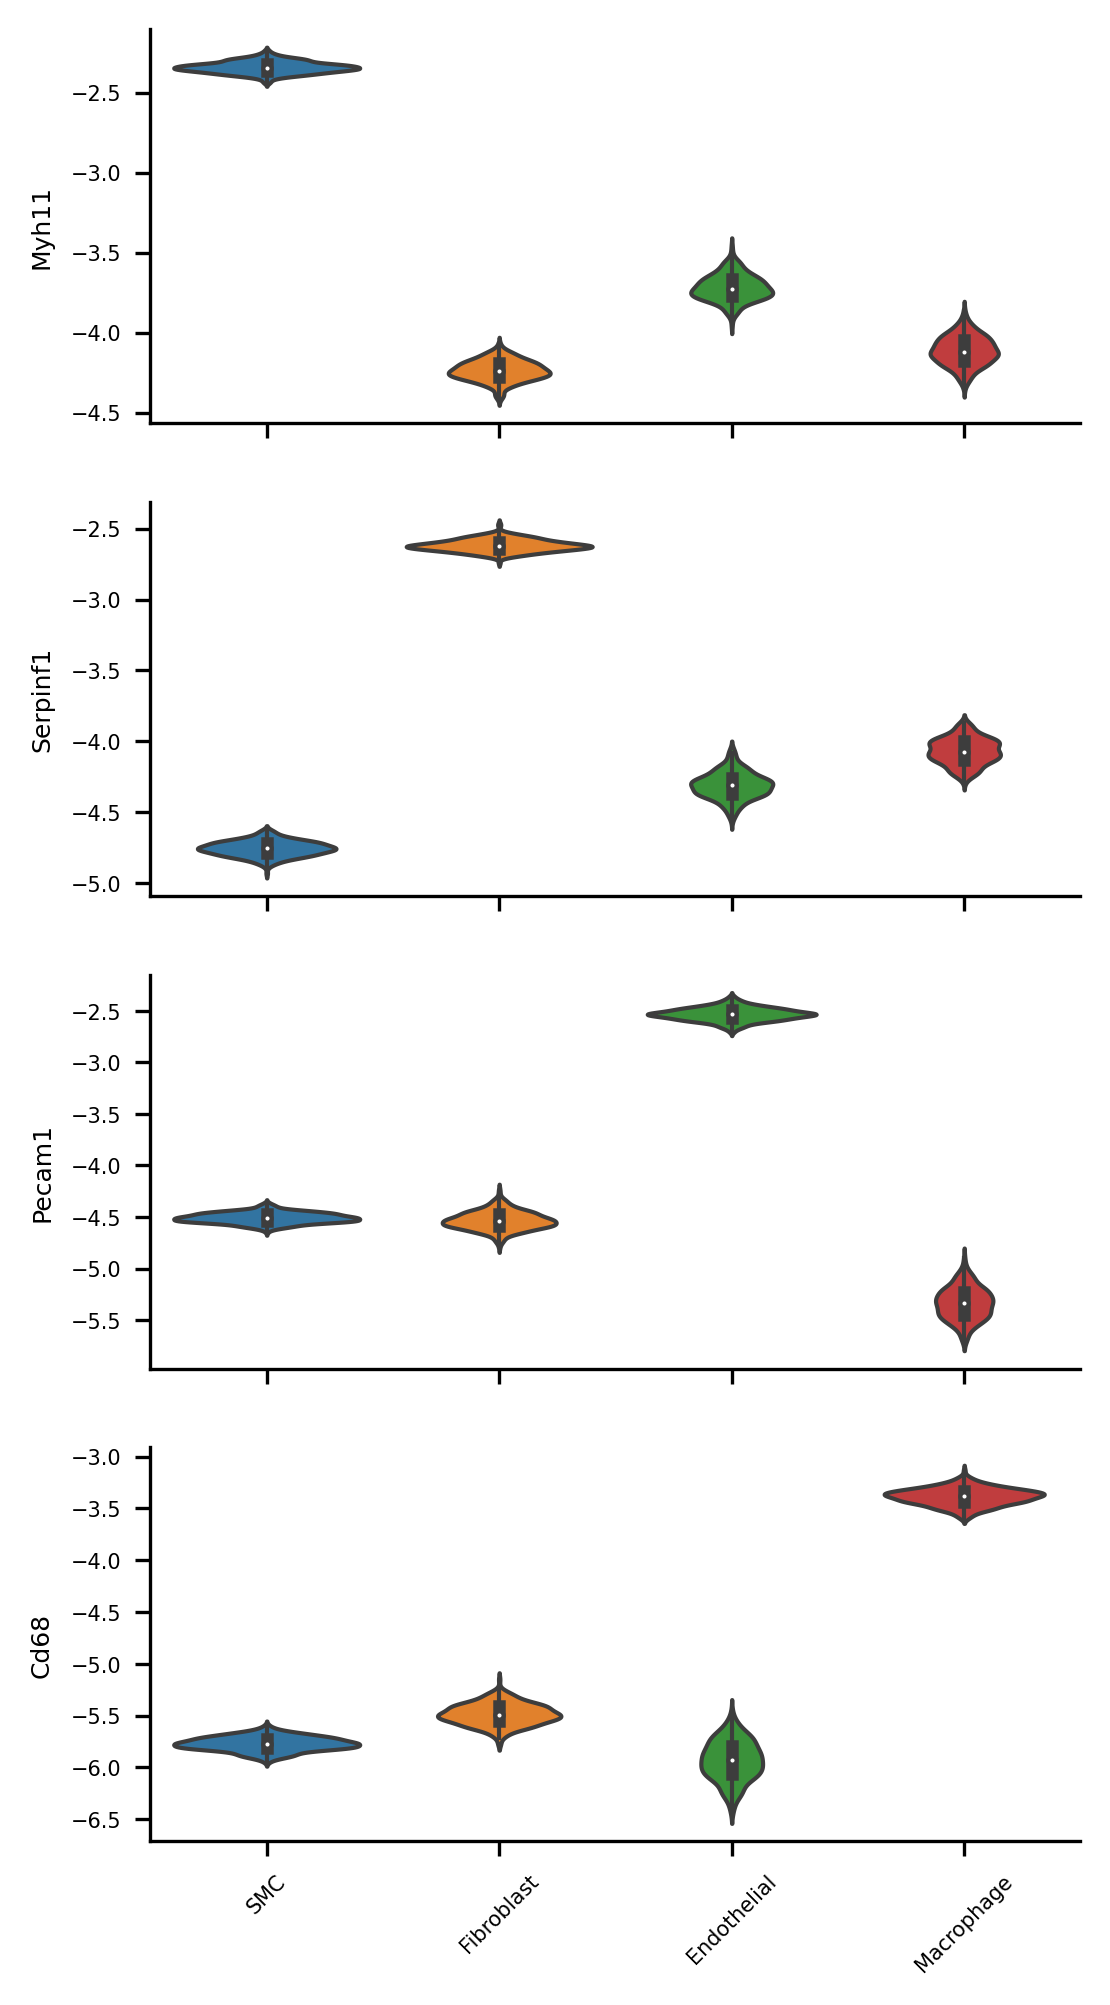

In [81]:
# --- MAKE THE STACKED VIOLIN FOR THE UP MARKERS ---


fig,axs = plt.subplots(figsize = (4,8),
                       ncols = 1,
                      nrows = len(marker_genes),
                     dpi = 300)




for gene_index,gene in enumerate(marker_genes):
    gene_df = pd.DataFrame()
    gene_df['Log10 prop'] = marker_adata[:,gene].X.flatten()
    gene_df['Cluster'] = np.array(marker_adata.obs['cluster_name'])
    sns.violinplot(x="Cluster", y="Log10 prop", data=gene_df,ax=axs[gene_index])
    sns.despine()
    # axs[gene_index].set_ylabel("%s\nlog10 prop" % gene)
    axs[gene_index].set_ylabel("%s" % gene)
plt.xticks(rotation = 45)


# ** grey out certain axes **
for gene_index in range(0,len(marker_genes) - 1):
    axs[gene_index].set_xticklabels([""] * len(clusters))
    axs[gene_index].set_xlabel("")
    
# ** get rid of "cluster" annotation below the cell types **
plt.xlabel("")


# ** savefig **
plt.savefig('%s/cluster_marker_violin_plots.pdf' % marker_folder_out,bbox_inches='tight')




In [92]:
# --- COMPUTE THE PAIRWISE MEAN DIFFERENCES ---

# get the pseudobulk mean mat
pseudocount_prop = 1e-7
unique_clusters = list(sorted(adata.obs['cluster'].unique()))
mean_mat = np.zeros((len(unique_clusters), adata.shape[1]))
for i, cluster in enumerate(unique_clusters):
    print(i)
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    mean_mat[i,:] = np.array(np.sum(cluster_adata.X,axis=0)).flatten() / np.sum(cluster_adata.obs['lib_size'])
mean_mat[mean_mat <= pseudocount_prop] = pseudocount_prop
mean_mat = np.log10(mean_mat)


# make the stat mat
up_stat_mat = np.zeros((len(unique_clusters), adata.shape[1]))
down_stat_mat = np.zeros((len(unique_clusters), adata.shape[1]))
for i, cluster in enumerate(unique_clusters):
    dif_mat = mean_mat[i,:] - mean_mat # [num_clusters x num_genes]
    dif_mat = np.concatenate((dif_mat[:i,:],dif_mat[i+1:,:]),axis=0)
    up_stat_vec = np.min(dif_mat,axis=0)
    up_stat_vec[up_stat_vec <= 0] = 0
    up_stat_mat[i,:] = up_stat_vec
    down_stat_vec = np.max(dif_mat,axis=0)
    down_stat_vec[down_stat_vec >= 0] = 0
    down_stat_mat[i,:]= down_stat_vec
    
    




0
1
2
3
4
5
6
7
8


In [93]:
# --- GET THE CANDIDATE MARKERS FOR EACH CLUSTER ---

median_prop_thresh = -4
up_stat_thresh = 0.1
# adj_p_val_thresh = 0.05
# num_top_markers_per_cluster = 2

cluster_up_df_list = []
candidate_markers = []
for cluster_index,cluster in enumerate(unique_clusters):
    
    # get the cluster marker df
    cluster_marker_df = pd.DataFrame()
    cluster_marker_df['gene'] = np.array(adata.var_names)
    cluster_marker_df = cluster_marker_df.set_index('gene')
    cluster_marker_df['up_stat'] = up_stat_mat[cluster_index,:]
    cluster_marker_df['down_stat'] = down_stat_mat[cluster_index,:]
    cluster_marker_df['median_log10_prop'] = mean_mat[cluster_index,:]
    
    # limit to markers
    condit_1 = cluster_marker_df['median_log10_prop'] >= median_prop_thresh
    condit_2 = cluster_marker_df['up_stat'] >= up_stat_thresh
#     condit_3 = cluster_marker_df['down_stat'] <= -1 * up_stat_thresh
#     condit_4 = cluster_marker_df['pval_adj'] <= adj_p_val_thresh
    cluster_up_df = cluster_marker_df[condit_1 & condit_2].sort_values(['up_stat'],ascending=False)

    # add to lists
    cluster_up_df_list.append(cluster_up_df)
    candidate_markers += list(cluster_up_df.index)
    print(len(cluster_up_df))
    


    
    

240
222
229
353
20
331
382
154
390


In [94]:
# --- MAKE CANDIDATE MARKER ADATA ---

candidate_marker_adata = adata[:,candidate_markers]
X_transformed = (np.array((candidate_marker_adata.X.todense()))) / np.array(candidate_marker_adata.obs['lib_size']).reshape(-1,1)
X_transformed[X_transformed <= pseudocount_prop] = pseudocount_prop
X_transformed = np.log10(X_transformed)
candidate_marker_adata.layers['X_transformed'] = X_transformed




In [95]:
# --- DO DE ---


candidate_marker_adata.obs['cluster'] = candidate_marker_adata.obs['cluster'].astype('category')
scanpy.tl.rank_genes_groups(candidate_marker_adata, use_raw = False, layer = 'X_transformed', groupby = 'cluster', n_genes = candidate_marker_adata.shape[1], method = 'wilcoxon')







In [96]:
# --- GET THE DE DF ---

def get_de_res_df(adata):

    result = adata.uns['rank_genes_groups']
    result_all=result
    groups = result['names'].dtype.names
    result_all_pd = pd.DataFrame({group + '_' + key[:1]: result[key][group] for group in groups for key in ['names', 'scores', 'pvals_adj']})
    
    return result_all_pd



de_df = get_de_res_df(candidate_marker_adata)




In [108]:
cluster = 8
de_df[['%s_n' % cluster, '%s_p' % cluster]]



,8_n,8_p
0,Clec1b,5.410728e-12
1,1810058I24Rik,5.410728e-12
2,Nrgn,5.410728e-12
3,Ctla2a,5.410728e-12
4,Tmsb4x,5.410728e-12
...,...,...
2316,Rps24,1.086545e-11
2317,Rps20,1.020236e-11
2318,Rps21,9.798527e-12
2319,Rps8,8.977503e-12
